# Quality Inspection of Casting Products — Transfer Learning & Fine-Tuning

This notebook performs **transfer learning** and **fine-tuning** on the
*Casting Product Image Data for Quality Inspection* dataset (binary classification:
`def_front` = defective vs `ok_front` = ok).

The data is **already augmented at the source**, so we do **not** apply any extra
data augmentation here — only the model-specific preprocessing.

**Pipeline**

1. Mount Google Drive and configure paths.
2. Inspect the dataset (class counts, sample images).
3. Build `tf.data` pipelines from the directory tree.
4. Build a transfer-learning model on top of **EfficientNetB0** (ImageNet weights).
5. **Phase 1** — train the classifier head with the base frozen.
6. **Phase 2** — unfreeze the top of the base and **fine-tune** with a small LR.
7. Evaluate on the test set: loss/accuracy, classification report, confusion matrix,
   ROC-AUC, PR curve, and a grid of sample predictions.
8. Save the final model.

> Why EfficientNetB0? It gives the best accuracy/compute trade-off on small
> industrial datasets like this one (~7k images), trains fast on a Colab GPU,
> and converges quickly with frozen-then-fine-tuned schedules.


## 1. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports and configuration

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset paths (matches the Drive layout in your screenshot)
DATA_ROOT = '/content/drive/MyDrive/casting_data/casting_data'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

# Image / training hyper-parameters
IMG_SIZE     = 224          # EfficientNetB0 native input
BATCH_SIZE   = 32
VAL_SPLIT    = 0.15         # carved out of the train folder for model selection
EPOCHS_HEAD  = 10           # phase 1: train the head only
EPOCHS_FT    = 10           # phase 2: fine-tune the top of the base
LR_HEAD      = 1e-3
LR_FT        = 1e-5         # MUCH smaller LR for fine-tuning
N_UNFREEZE   = 40           # number of top base-layers to unfreeze in phase 2

# Class order: index 0 = ok, index 1 = defective (positive class for QC)
CLASS_NAMES  = ['ok_front', 'def_front']

assert os.path.isdir(TRAIN_DIR), f'Train dir not found: {TRAIN_DIR}'
assert os.path.isdir(TEST_DIR),  f'Test  dir not found: {TEST_DIR}'
print('Train dir:', TRAIN_DIR)
print('Test  dir:', TEST_DIR)

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train dir: /content/drive/MyDrive/casting_data/casting_data/train
Test  dir: /content/drive/MyDrive/casting_data/casting_data/test


## 3. Inspect the dataset

In [6]:
def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
print('Train counts:', train_counts, ' total =', sum(train_counts.values()))
print('Test  counts:', test_counts,  ' total =', sum(test_counts.values()))

Train counts: {'def_front': 3758, 'ok_front': 2891}  total = 6649
Test  counts: {'def_front': 453, 'ok_front': 262}  total = 715


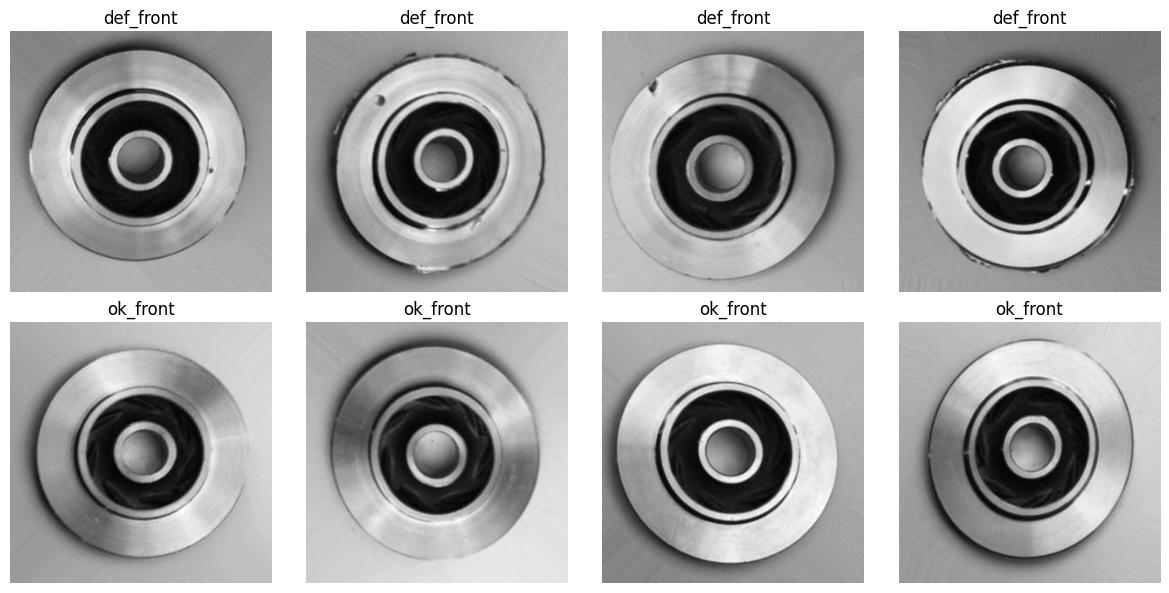

In [7]:
# Plot a few sample images per class from the train set
def show_samples(folder, n_per_class=4):
    classes = sorted(os.listdir(folder))
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3*n_per_class, 3*len(classes)))
    if len(classes) == 1:
        axes = np.array([axes])
    for r, cls in enumerate(classes):
        cls_path = os.path.join(folder, cls)
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        sample = random.sample(files, min(n_per_class, len(files)))
        for c, fname in enumerate(sample):
            img = keras.utils.load_img(os.path.join(cls_path, fname))
            axes[r, c].imshow(img)
            axes[r, c].set_title(cls)
            axes[r, c].axis('off')
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR)

## 4. Build `tf.data` pipelines

We use `image_dataset_from_directory`, which infers labels from the folder
structure. We carve a small validation split out of the train folder for model
selection, and keep the test folder strictly held-out.

Because the source data is already augmented, the pipeline only:
* resizes to the model's native input size, and
* applies EfficientNet's official `preprocess_input`.


In [8]:
train_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training',
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation',
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class names (model order):', train_ds_raw.class_names)
print('Train batches:', tf.data.experimental.cardinality(train_ds_raw).numpy())
print('Val   batches:', tf.data.experimental.cardinality(val_ds_raw).numpy())
print('Test  batches:', tf.data.experimental.cardinality(test_ds_raw).numpy())

Found 6649 files belonging to 2 classes.
Using 5652 files for training.
Found 6649 files belonging to 2 classes.
Using 997 files for validation.
Found 715 files belonging to 2 classes.
Class names (model order): ['ok_front', 'def_front']
Train batches: 177
Val   batches: 32
Test  batches: 23


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
preprocess = keras.applications.efficientnet.preprocess_input

def _prep(x, y):
    return preprocess(x), y

train_ds = train_ds_raw.map(_prep, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(_prep,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(_prep,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

## 5. Build the transfer-learning model

We pick **EfficientNetB0** because it is the most compatible architecture for
this dataset:

* Pre-trained on ImageNet → strong low-level filters that transfer well to
  industrial imagery.
* ~5M parameters → fast on a Colab GPU and unlikely to overfit ~7k images.
* Native 224×224 input → a good match for the source augmentation pipeline.
* Compound scaling makes it robust across image sizes.

The head is a `GlobalAveragePooling2D` → `Dropout` → `Dense(1, sigmoid)` for
binary classification.


In [10]:
def build_model():
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False  # phase 1: freeze the base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='effnetb0_casting')
    return model, base_model

model, base_model = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "effnetb0_casting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Phase 1 — train the head with the base frozen

The base network is frozen so that the gradient signal only updates the new
classifier head. This warms up the head before any backbone weights are
touched (otherwise large gradients from a randomly-initialised head would wreck
the pre-trained features).


In [11]:
callbacks_phase1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_phase1,
    verbose=1,
)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 649s 3s/step - accuracy: 0.8422 - auc: 0.9297 - loss: 0.4151 - val_accuracy: 0.9709 - val_auc: 0.9935 - val_loss: 0.2445 - learning_rate: 0.0010
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9397 - auc: 0.9851 - loss: 0.2372 - val_accuracy: 0.9829 - val_auc: 0.9942 - val_loss: 0.1647 - learning_rate: 0.0010
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9551 - auc: 0.9900 - loss: 0.1831 - val_accuracy: 0.9870 - val_auc: 0.9947 - val_loss: 0.1278 - learning_rate: 0.0010
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9616 - auc: 0.9929 - loss: 0.1515 - val_accuracy: 0.9870 - val_auc: 0.9951 - val_loss: 0.1095 - learning_rate: 0.0010
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9678 - auc: 0.9937 - loss: 0.1354 - val_accuracy: 0.9890 - val_auc: 0.9954 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9683 - 

## 7. Phase 2 — fine-tune the top of the base

We unfreeze the top `N_UNFREEZE` layers of EfficientNetB0 and recompile with a
**much smaller learning rate** (`1e-5`). Lower layers stay frozen because they
encode generic features (edges, textures) that we do not want to disturb.


In [12]:
# Unfreeze the top of the base; keep BatchNorm layers frozen so their
# running statistics from ImageNet stay intact.
base_model.trainable = True
for layer in base_model.layers[:-N_UNFREEZE]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Trainable parameters after unfreezing: {trainable_params:,}')

model.compile(
    optimizer=keras.optimizers.Adam(LR_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_phase2,
    verbose=1,
)

Trainable parameters after unfreezing: 2,038,801
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 66s 206ms/step - accuracy: 0.9811 - auc: 0.9970 - loss: 0.0702 - val_accuracy: 0.9910 - val_auc: 0.9971 - val_loss: 0.0421 - learning_rate: 1.0000e-05
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.9889 - auc: 0.9980 - loss: 0.0481 - val_accuracy: 0.9910 - val_auc: 0.9977 - val_loss: 0.0351 - learning_rate: 1.0000e-05
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9864 - auc: 0.9977 - loss: 0.0460 - val_accuracy: 0.9920 - val_auc: 0.9985 - val_loss: 0.0324 - learning_rate: 1.0000e-05
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9910 - auc: 0.9983 - loss: 0.0361 - val_accuracy: 0.9930 - val_auc: 0.9988 - val_loss: 0.0280 - learning_rate: 1.0000e-05
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9913 - auc: 0.9984 - loss: 0.0339 - val_accuracy: 0.9900 - val_auc: 0.9989 - val_loss: 0.0288 - learning_rate: 1.0000e-05
Epo

## 8. Training curves

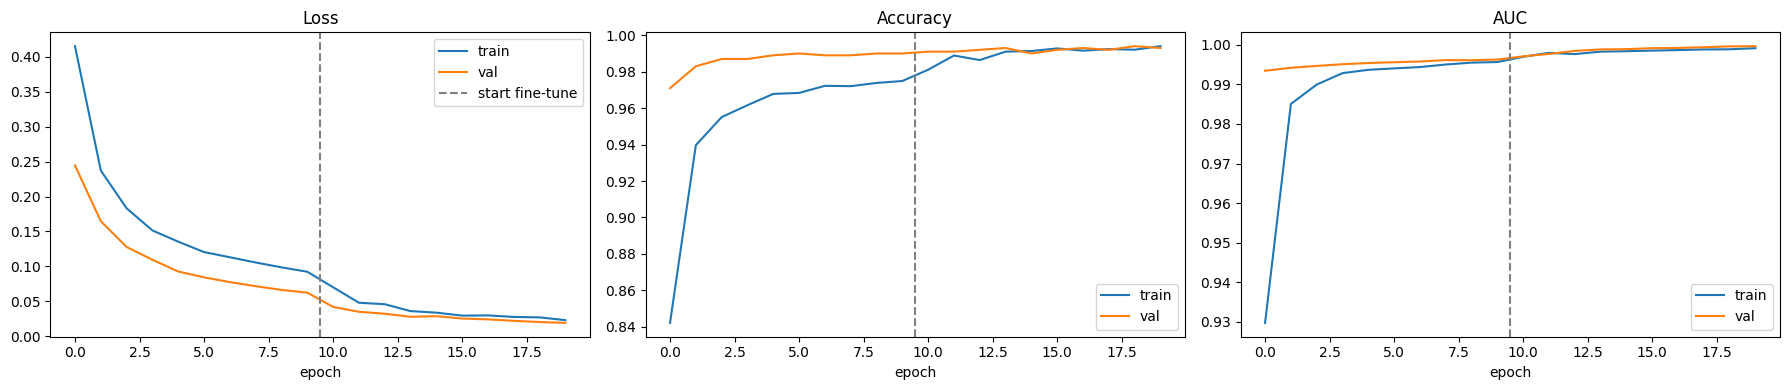

In [13]:
def merge_histories(*hists):
    out = {}
    for h in hists:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

H = merge_histories(history_phase1, history_phase2)
n_phase1 = len(history_phase1.history['loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(H['loss'],     label='train')
axes[0].plot(H['val_loss'], label='val')
axes[0].axvline(n_phase1 - 0.5, color='gray', linestyle='--', label='start fine-tune')
axes[0].set_title('Loss');     axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(H['accuracy'],     label='train')
axes[1].plot(H['val_accuracy'], label='val')
axes[1].axvline(n_phase1 - 0.5, color='gray', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()

axes[2].plot(H['auc'],     label='train')
axes[2].plot(H['val_auc'], label='val')
axes[2].axvline(n_phase1 - 0.5, color='gray', linestyle='--')
axes[2].set_title('AUC');      axes[2].set_xlabel('epoch'); axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on the test set

We compute:

* test loss / accuracy / AUC,
* classification report (precision / recall / F1),
* confusion matrix,
* ROC and Precision–Recall curves,
* a grid of sample predictions (correct + incorrect).

The **positive class is `def_front`** (defective), so `recall` here is the
fraction of real defects that we caught — the most important metric for a
quality-inspection system.


In [14]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc as sk_auc,
    precision_recall_curve, average_precision_score,
)

# 1. Overall metrics from Keras
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')
print(f'Test AUC      : {test_auc:.4f}')

# 2. Predictions
y_true = np.concatenate([y.numpy().ravel() for _, y in test_ds], axis=0).astype(int)
y_prob = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('\nClassification report (positive class = def_front):')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Test loss     : 0.0202
Test accuracy : 0.9944
Test AUC      : 0.9992

Classification report (positive class = def_front):
              precision    recall  f1-score   support

    ok_front     0.9886    0.9962    0.9924       262
   def_front     0.9978    0.9934    0.9956       453

    accuracy                         0.9944       715
   macro avg     0.9932    0.9948    0.9940       715
weighted avg     0.9944    0.9944    0.9944       715



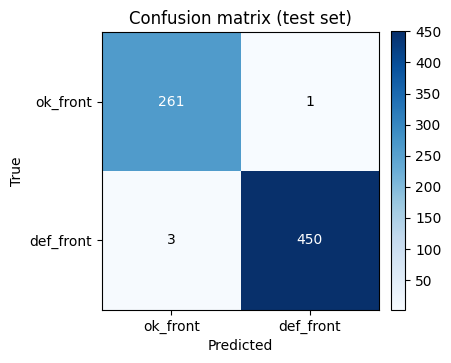

In [15]:
# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (test set)')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

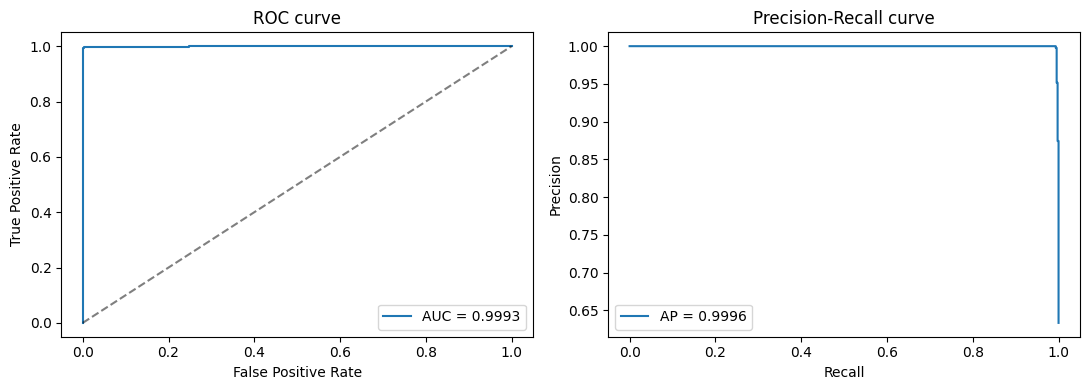

In [16]:
# 4. ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = sk_auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve'); axes[0].legend()

axes[1].plot(rec, prec, label=f'AP = {ap:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve'); axes[1].legend()

plt.tight_layout()
plt.show()

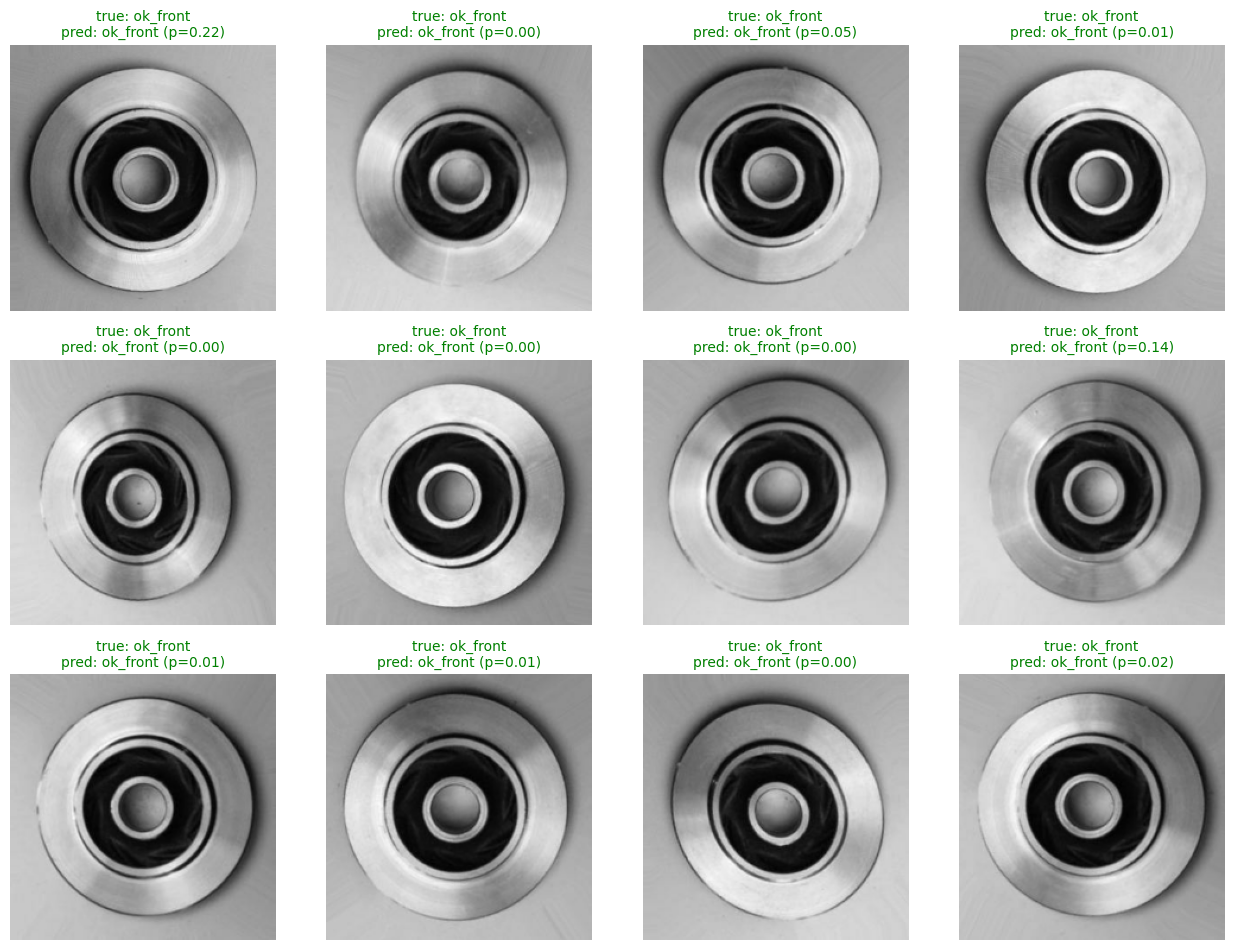

In [17]:
# 5. Visualise some predictions (mix of correct + incorrect)
# We re-pull a batch from the *raw* test pipeline so the images are still in [0, 255]
# (more readable than the EfficientNet-preprocessed tensors).
sample_imgs, sample_labels = next(iter(test_ds_raw))
sample_probs = model.predict(preprocess(sample_imgs), verbose=0).ravel()
sample_preds = (sample_probs >= 0.5).astype(int)
sample_true  = sample_labels.numpy().ravel().astype(int)

n_show = min(12, sample_imgs.shape[0])
cols = 4
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 3.2*rows))
axes = axes.ravel()
for i in range(n_show):
    axes[i].imshow(sample_imgs[i].numpy().astype('uint8'))
    color = 'green' if sample_preds[i] == sample_true[i] else 'red'
    axes[i].set_title(
        f'true: {CLASS_NAMES[sample_true[i]]}\n'
        f'pred: {CLASS_NAMES[sample_preds[i]]} (p={sample_probs[i]:.2f})',
        color=color, fontsize=10,
    )
    axes[i].axis('off')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 10. Save the fine-tuned model

In [18]:
SAVE_DIR = '/content/drive/MyDrive/casting_data/models'
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, 'effnetb0_casting_finetuned.keras')
model.save(model_path)
print('Saved model to:', model_path)

Saved model to: /content/drive/MyDrive/casting_data/models/effnetb0_casting_finetuned.keras


### Re-loading the saved model

```python
from tensorflow import keras
model = keras.models.load_model(
    '/content/drive/MyDrive/casting_data/models/effnetb0_casting_finetuned.keras'
)
```
